In [2]:
import pandas as pd

df_exp = pd.read_csv("../data/raw/df_final_experiment_clients.txt")

In [3]:
df_exp 

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control
...,...,...
70604,2443347,NaN
70605,8788427,NaN
70606,266828,NaN
70607,1266421,NaN


In [4]:

# initial structure
print(df_exp.info())
print(df_exp.head())

<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   client_id  70609 non-null  int64
 1   Variation  50500 non-null  str  
dtypes: int64(1), str(1)
memory usage: 1.1 MB
None
   client_id Variation
0    9988021      Test
1    8320017      Test
2    4033851   Control
3    1982004      Test
4    9294070   Control


In [5]:
#  remove rows with missing values
df_exp = df_exp.dropna(subset=["client_id", "Variation"])

In [6]:
#  remove duplicates
df_exp= df_exp.drop_duplicates(subset=["client_id"])


In [7]:
# clean text in Variation column
df_exp["Variation"] = df_exp["Variation"].str.strip().str.lower()

In [8]:
# ensure correct type
df_exp["client_id"] = df_exp["client_id"].astype(int)

In [9]:
# check missing values
print(df_exp.isna().sum())

# check duplicates
print(df_exp.duplicated().sum())

# check unique values
print(df_exp["Variation"].unique())

client_id    0
Variation    0
dtype: int64
0
<StringArray>
['test', 'control']
Length: 2, dtype: str


In [10]:
# check unique values
print(df_exp["Variation"].value_counts())


Variation
test       26968
control    23532
Name: count, dtype: int64


In [11]:
# save cleaned dataset
df_exp.to_csv("df_final_experiment_clients_clean.csv", index=False)

In [21]:
variation_percent = df["Variation"].value_counts(normalize=True) * 100

print(variation_percent)

Variation
test       53.40198
control    46.59802
Name: proportion, dtype: float64


In [1]:
###############

In [2]:
import pandas as pd
import seaborn as sns
import yaml
import matplotlib.pyplot as plt
import numpy as np

In [3]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

In [4]:
file1_path = config["output_data"]["file1"]

In [5]:
demo_df_cleaned = pd.read_csv(file1_path)

In [6]:
demo_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70595 entries, 0 to 70594
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70595 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  object 
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 4.8+ MB


In [7]:
demo_df_cleaned.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [8]:
file2_path = config["output_data"]["file2"]

In [9]:
df_ec = pd.read_csv(file2_path)

In [10]:
df_ec.head()

,client_id,Variation
0,9988021,test
1,8320017,test
2,4033851,control
3,1982004,test
4,9294070,control


In [11]:
df_ec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50500 entries, 0 to 50499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  50500 non-null  int64 
 1   Variation  50500 non-null  object
dtypes: int64(1), object(1)
memory usage: 789.2+ KB


In [12]:
file7_path = config["output_data"]["file7"]

In [13]:
df_web = pd.read_csv(file7_path)  

In [14]:
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318706 entries, 0 to 318705
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     318706 non-null  int64 
 1   visitor_id    318706 non-null  object
 2   visit_id      318706 non-null  object
 3   process_step  318706 non-null  object
 4   date_time     318706 non-null  object
dtypes: int64(1), object(4)
memory usage: 12.2+ MB


In [15]:
df_web.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56
1,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03
2,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35
3,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14
4,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34


In [16]:
import pandas as pd

# ============================================================
# 1. Identify which clients appear in the online process data
# ============================================================
# df_web contains one row per web event / process step.
# Since the same client can appear multiple times, we extract
# unique client IDs to identify all clients who used the online process.

online_client_ids = df_web["client_id"].unique()

# Optional check: how many unique clients used the online process?
n_online_clients = len(online_client_ids)
print("Number of unique clients in df_web:", n_online_clients)


# ============================================================
# 2. Filter the demographic dataset to keep only online users
# ============================================================
# demo_df_cleaned contains the client profile information.
# We keep only the clients whose client_id appears in df_web.

online_clients_demo = demo_df_cleaned[
    demo_df_cleaned["client_id"].isin(online_client_ids)
].copy()

# Optional check: how many matched clients do we have in the demo dataset?
print("Number of matched online clients in demographic data:", online_clients_demo["client_id"].nunique())


# ============================================================
# 3. Create a baseline dataset with all clients
# ============================================================
# This will allow us to compare online users against the full
# client population, which is essential to answer:
# "Who are the primary clients using this online process?"

all_clients_demo = demo_df_cleaned.copy()

print("Total number of clients in demographic data:", all_clients_demo["client_id"].nunique())


# ============================================================
# 4. Measure online process adoption rate
# ============================================================
# This tells us what share of all demographic clients used the online process.

adoption_rate = online_clients_demo["client_id"].nunique() / all_clients_demo["client_id"].nunique()
print(f"Online process adoption rate: {adoption_rate:.2%}")

Number of unique clients in df_web: 49911
Number of matched online clients in demographic data: 49911
Total number of clients in demographic data: 70595
Online process adoption rate: 70.70%


In [17]:
# ============================================================
# 5. Compare numerical variables: overall vs online users
# ============================================================
# We calculate descriptive statistics for key client features
# such as age, tenure, balance, number of accounts, calls, and logons.

numeric_cols = [
    "clnt_tenure_yr",
    "clnt_tenure_mnth",
    "clnt_age",
    "num_accts",
    "bal",
    "calls_6_mnth",
    "logons_6_mnth"
]

# Summary statistics for all clients
all_numeric_summary = all_clients_demo[numeric_cols].describe()

# Summary statistics for online clients only
online_numeric_summary = online_clients_demo[numeric_cols].describe()

print("Summary statistics - All clients")
display(all_numeric_summary)

print("Summary statistics - Online clients")
display(online_numeric_summary)

Summary statistics - All clients


,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,70595.000000,70595.000000,70594.000000,70595.000000,7.059500e+04,70595.000000,70595.000000
mean,12.052950,150.659367,46.442240,2.255528,1.474452e+05,3.382478,5.566740
std,6.871819,82.089854,15.591273,0.534997,3.015087e+05,2.236580,2.353286
min,2.000000,33.000000,13.500000,1.000000,1.378942e+04,0.000000,1.000000
25%,6.000000,82.000000,32.500000,2.000000,3.734683e+04,1.000000,4.000000
50%,11.000000,136.000000,47.000000,2.000000,6.333290e+04,3.000000,5.000000
75%,16.000000,192.000000,59.000000,2.000000,1.375449e+05,6.000000,7.000000
max,62.000000,749.000000,96.000000,8.000000,1.632004e+07,7.000000,9.000000


Summary statistics - Online clients


,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,bal,calls_6_mnth,logons_6_mnth
count,49911.00000,49911.000000,49910.000000,49911.000000,4.991100e+04,49911.000000,49911.000000
mean,11.99441,149.970347,47.238910,2.251307,1.484760e+05,3.089640,6.127587
std,6.82906,81.572214,15.474597,0.530362,3.008904e+05,2.187453,2.175037
min,2.00000,33.000000,17.000000,1.000000,2.378944e+04,0.000000,3.000000
25%,6.00000,82.000000,33.500000,2.000000,3.982138e+04,1.000000,4.000000
50%,11.00000,135.000000,48.000000,2.000000,6.548685e+04,3.000000,6.000000
75%,15.00000,191.000000,59.500000,2.000000,1.388361e+05,5.000000,8.000000
max,55.00000,669.000000,96.000000,7.000000,1.632004e+07,6.000000,9.000000


In [18]:
# ============================================================
# 6. Compare mean values directly
# ============================================================
# This provides a simple and practical way to see whether
# online users differ from the average client.

comparison_means = pd.DataFrame({
    "all_clients_mean": all_clients_demo[numeric_cols].mean(),
    "online_clients_mean": online_clients_demo[numeric_cols].mean()
})

# Compute the absolute difference
comparison_means["difference"] = (
    comparison_means["online_clients_mean"] - comparison_means["all_clients_mean"]
)

# Compute the relative difference in percentage terms
comparison_means["pct_difference"] = (
    comparison_means["difference"] / comparison_means["all_clients_mean"] * 100
)

print("Mean comparison: All clients vs Online clients")
display(comparison_means.sort_values(by="pct_difference", ascending=False))

Mean comparison: All clients vs Online clients


,all_clients_mean,online_clients_mean,difference,pct_difference
logons_6_mnth,5.566740,6.127587,0.560847,10.074968
clnt_age,46.442240,47.238910,0.796670,1.715399
bal,147445.240641,148476.020605,1030.779964,0.699093
num_accts,2.255528,2.251307,-0.004221,-0.187126
clnt_tenure_mnth,150.659367,149.970347,-0.689020,-0.457336
clnt_tenure_yr,12.052950,11.994410,-0.058540,-0.485689
calls_6_mnth,3.382478,3.089640,-0.292838,-8.657499


In [20]:
# ============================================================
# 8. Add a flag indicating whether a client used the online process
# ============================================================
# This creates a single analysis table that can be grouped easily.

client_profile = demo_df_cleaned.copy()

client_profile["used_online_process"] = client_profile["client_id"].isin(online_client_ids)

print(client_profile["used_online_process"].value_counts())

used_online_process
True     49911
False    20684
Name: count, dtype: int64


In [21]:
# ============================================================
# 9. Group by online usage flag and compare mean characteristics
# ============================================================
# False = clients in demographic dataset who did not appear in df_web
# True  = clients who used the online process

grouped_profile = client_profile.groupby("used_online_process")[numeric_cols].mean().T
grouped_profile.columns = ["did_not_use_online", "used_online"]

# Calculate difference between online users and non-users
grouped_profile["difference"] = grouped_profile["used_online"] - grouped_profile["did_not_use_online"]

print("Average profile: Online users vs Non-users")
display(grouped_profile)

Average profile: Online users vs Non-users


,did_not_use_online,used_online,difference
clnt_tenure_yr,12.194208,11.994410,-0.199798
clnt_tenure_mnth,152.321988,149.970347,-2.351641
clnt_age,44.519895,47.238910,2.719015
num_accts,2.265713,2.251307,-0.014405
bal,144957.943273,148476.020605,3518.077332
calls_6_mnth,4.089103,3.089640,-0.999463
logons_6_mnth,4.213402,6.127587,1.914185


In [22]:
# ============================================================
# 10. Create age groups to profile online users
# ============================================================
# Grouping age into bands makes the audience profile easier to interpret.

client_profile["age_group"] = pd.cut(
    client_profile["clnt_age"],
    bins=[0, 30, 40, 50, 60, 70, 120],
    labels=["<30", "30-39", "40-49", "50-59", "60-69", "70+"]
)

# Distribution of age groups among online users
age_dist_online = (
    client_profile[client_profile["used_online_process"]]["age_group"]
    .value_counts(normalize=True)
    .sort_index()
)

# Distribution of age groups in the full client base
age_dist_all = (
    client_profile["age_group"]
    .value_counts(normalize=True)
    .sort_index()
)

age_comparison = pd.concat([age_dist_all.rename("all_clients_pct"),
                            age_dist_online.rename("online_clients_pct")], axis=1)

age_comparison["difference"] = age_comparison["online_clients_pct"] - age_comparison["all_clients_pct"]

print("Age group comparison")
display(age_comparison)

Age group comparison


,all_clients_pct,online_clients_pct,difference
age_group,,,
<30,0.198657,0.180124,-0.018533
30-39,0.183160,0.188980,0.005820
40-49,0.178344,0.174654,-0.003689
50-59,0.220260,0.220236,-0.000023
60-69,0.163909,0.174955,0.011046
70+,0.055670,0.061050,0.005379


In [101]:
# ============================================================
# 12. Build a compact summary table
# ============================================================
# This table can help support the final business conclusion.

summary_table = pd.DataFrame({
    "metric": numeric_cols,
    "all_clients_mean": [all_clients_demo[col].mean() for col in numeric_cols],
    "online_clients_mean": [online_clients_demo[col].mean() for col in numeric_cols]
})

summary_table["difference"] = summary_table["online_clients_mean"] - summary_table["all_clients_mean"]
summary_table["pct_difference"] = (summary_table["difference"] / summary_table["all_clients_mean"]) * 100

display(summary_table.sort_values(by="pct_difference", ascending=False))

,metric,all_clients_mean,online_clients_mean,difference,pct_difference
5,logons_6_mnth,5.566740,6.127587,0.560847,10.074968
0,clnt_age,46.442240,47.238910,0.796670,1.715399
3,bal,147445.240641,148476.020605,1030.779964,0.699093
2,num_accts,2.255528,2.251307,-0.004221,-0.187126
1,clnt_tenure_yr,12.052950,11.994410,-0.058540,-0.485689
4,calls_6_mnth,3.382478,3.089640,-0.292838,-8.657499


## Are the primary clients younger or older, new or long-standing?

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Optional: improve aesthetics
sns.set(style="whitegrid")

# Reuse this merged dataset with a flag
client_profile = demo_df_cleaned.copy()
client_profile["used_online_process"] = client_profile["client_id"].isin(df_web["client_id"].unique())

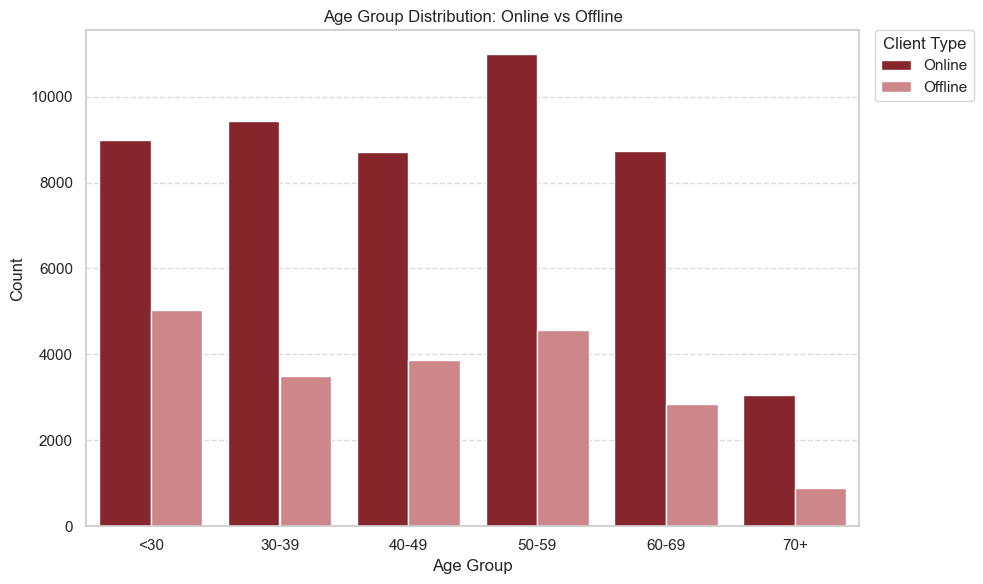

In [127]:
# ============================================================
# Plot: Age group distribution (Online first)
# ============================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Rebuild client_profile
client_profile = demo_df_cleaned.copy()

# Create flag
online_client_ids = df_web["client_id"].unique()
client_profile["used_online_process"] = client_profile["client_id"].isin(online_client_ids)

# Age groups
client_profile["age_group"] = pd.cut(
    client_profile["clnt_age"],
    bins=[0, 30, 40, 50, 60, 70, 120],
    labels=["<30", "30-39", "40-49", "50-59", "60-69", "70+"]
)

# Aggregate
age_group_df = (
    client_profile
    .groupby(["age_group", "used_online_process"], observed=False)
    .size()
    .reset_index(name="count")
)

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=age_group_df,
    x="age_group",
    y="count",
    hue="used_online_process",
    hue_order=[True, False],  # 🔥 ONLINE FIRST
    palette={
        True: "#96151D",      # Online
        False: "#D97A7F"      # Offline
    }
)

plt.title("Age Group Distribution: Online vs Offline")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Fix legend (order must match hue_order)
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles,
    ["Online", "Offline"],   # 🔥 MATCH ORDER
    title="Client Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()

# ============================================================
# Save figure
# ============================================================
figures_dir = Path.cwd().parent / "Figures"
figures_dir.mkdir(exist_ok=True)

plt.savefig(
    figures_dir / "age_group_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

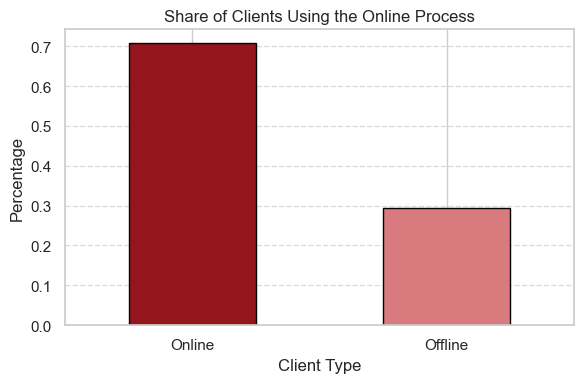

In [128]:
# ============================================================
# Plot: Online vs Non-online client share (Online first)
# ============================================================
import matplotlib.pyplot as plt
from pathlib import Path

# ensure column exists
client_profile["used_online_process"] = client_profile["client_id"].isin(df_web["client_id"].unique())

usage_counts = client_profile["used_online_process"].value_counts(normalize=True)

# 🔥 reorder → ONLINE FIRST
usage_counts = usage_counts.reindex([True, False])

plt.figure(figsize=(6, 4))

usage_counts.plot(
    kind="bar",
    color=["#96151D", "#D97A7F"],  # Online, Offline
    edgecolor="black"
)

plt.title("Share of Clients Using the Online Process")
plt.xlabel("Client Type")
plt.ylabel("Percentage")

# labels aligned with order
plt.xticks(ticks=[0, 1], labels=["Online", "Offline"], rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

# ============================================================
# Save figure
# ============================================================
figures_dir = Path.cwd().parent / "Figures"
figures_dir.mkdir(exist_ok=True)

plt.savefig(
    figures_dir / "client_share_online_vs_non_online.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [38]:
# ============================================================
# Create client tenure segments
# ============================================================
client_profile = demo_df_cleaned.copy()

client_profile["client_segment"] = client_profile["clnt_tenure_yr"].apply(
    lambda x: "New" if x < 5 else "Long-standing"
)

In [39]:
# ============================================================
# Count clients per segment
# ============================================================
segment_counts = client_profile["client_segment"].value_counts()
print(segment_counts)

client_segment
Long-standing    65378
New               5217
Name: count, dtype: int64


In [40]:
# ============================================================
# Convert counts to percentage
# ============================================================
segment_pct = client_profile["client_segment"].value_counts(normalize=True)

print(segment_pct)

client_segment
Long-standing    0.9261
New              0.0739
Name: proportion, dtype: float64


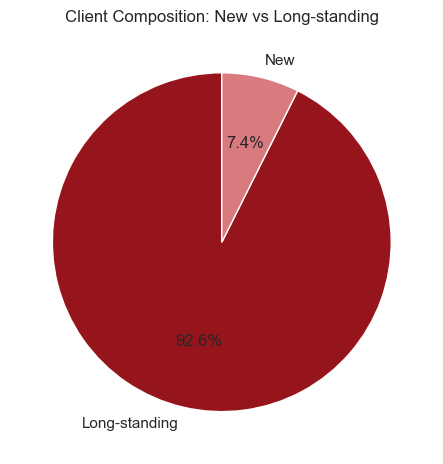

In [122]:
# ============================================================
# Plot: Pie chart (with save to Figures)
# ============================================================
import matplotlib.pyplot as plt
from pathlib import Path

plt.figure()

segment_pct.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)

plt.title("Client Composition: New vs Long-standing")
plt.ylabel("")

plt.tight_layout()

# ============================================================
# Save figure to ../Figures
# ============================================================
figures_dir = Path.cwd().parent / "Figures"
figures_dir.mkdir(exist_ok=True)

plt.savefig(
    figures_dir / "client_composition_pie.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Experiment struture

Was the experiment well-structured?

Were clients randomly and equally divided between the old and new designs?



In [46]:
# ============================================================
# Merge experiment assignment (df_ec) with demographics
# ============================================================
df_exp = df_ec.copy()

df_merged = df_exp.merge(
    demo_df_cleaned,
    on="client_id",
    how="left"
)

print(df_merged.head())

   client_id Variation  clnt_tenure_yr  clnt_tenure_mnth  clnt_age gendr  \
0    9988021      test             5.0              64.0      79.0     U   
1    8320017      test            22.0             274.0      34.5     M   
2    4033851   control            12.0             149.0      63.5     M   
3    1982004      test             6.0              80.0      44.5     U   
4    9294070   control             5.0              70.0      29.0     U   

   num_accts        bal  calls_6_mnth  logons_6_mnth  
0        2.0  189023.86           1.0            4.0  
1        2.0   36001.90           5.0            8.0  
2        2.0  142642.26           5.0            8.0  
3        2.0   30231.76           1.0            4.0  
4        2.0   34254.54           0.0            3.0  


In [48]:
# ============================================================
# Check group balance
# ============================================================
group_counts = df_merged["Variation"].value_counts()
group_pct = df_merged["Variation"].value_counts(normalize=True)

print("Counts:\n", group_counts)
print("\nPercentages:\n", group_pct)

Counts:
 Variation
test       26968
control    23532
Name: count, dtype: int64

Percentages:
 Variation
test       0.53402
control    0.46598
Name: proportion, dtype: float64


In [56]:
print(df_merged["Variation"].value_counts())

Variation
test       26968
control    23532
Name: count, dtype: int64


In [59]:
for col in numeric_cols:
    print(f"\n{col}")
    print(df_merged.groupby("Variation")[col].apply(lambda x: x.isna().mean()))


clnt_age
Variation
control    0.000255
test       0.000260
Name: clnt_age, dtype: float64

clnt_tenure_yr
Variation
control    0.000212
test       0.000260
Name: clnt_tenure_yr, dtype: float64

num_accts
Variation
control    0.000212
test       0.000260
Name: num_accts, dtype: float64

bal
Variation
control    0.000212
test       0.000260
Name: bal, dtype: float64

calls_6_mnth
Variation
control    0.000212
test       0.000260
Name: calls_6_mnth, dtype: float64

logons_6_mnth
Variation
control    0.000212
test       0.000260
Name: logons_6_mnth, dtype: float64


In [60]:
print(df_merged.isna().mean().sort_values(ascending=False))

clnt_age            0.000257
clnt_tenure_yr      0.000238
clnt_tenure_mnth    0.000238
gendr               0.000238
num_accts           0.000238
bal                 0.000238
calls_6_mnth        0.000238
logons_6_mnth       0.000238
client_id           0.000000
Variation           0.000000
dtype: float64


In [103]:
print(df_merged["clnt_age"].notna().mean())

0.9997425742574257


In [64]:
df_ec["in_demo"] = df_ec["client_id"].isin(demo_df_cleaned["client_id"])

print(df_ec.groupby("Variation")["in_demo"].mean())

Variation
control    0.999788
test       0.999740
Name: in_demo, dtype: float64


In [68]:
from scipy.stats import ttest_ind

for col in numeric_cols:
    control = df_merged[df_merged["Variation"] == "control"][col].dropna()
    test = df_merged[df_merged["Variation"] == "test"][col].dropna()
    
    if len(control) == 0 or len(test) == 0:
        print(f"{col}  skipped (empty group)")
        continue
    
    stat, p = ttest_ind(control, test)
    print(f"{col}  p-value: {p}")

clnt_age  p-value: 0.015689311849750098
clnt_tenure_yr  p-value: 0.08688829385193997
num_accts  p-value: 0.03574467958566245
bal  p-value: 0.6601898252929153
calls_6_mnth  p-value: 0.0005681264448310486
logons_6_mnth  p-value: 0.0009012772263658811


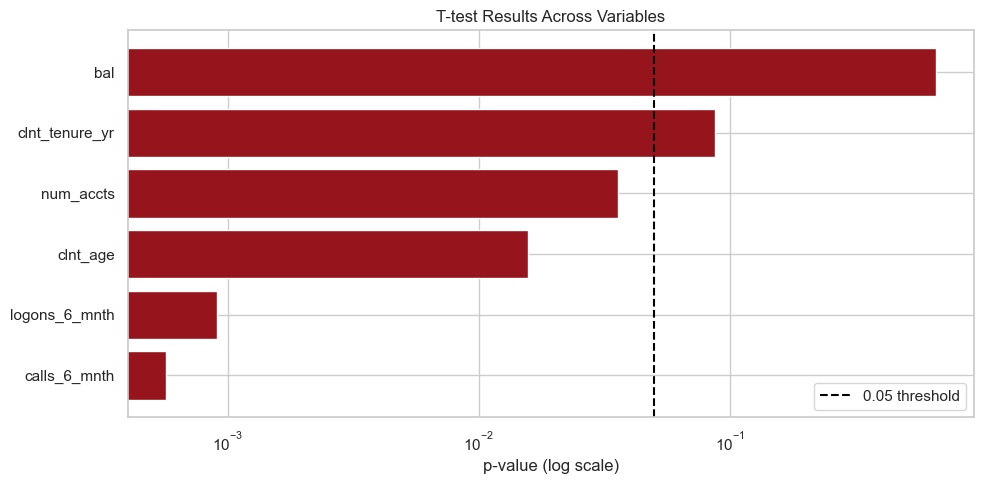

In [134]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from pathlib import Path

results = []

for col in numeric_cols:
    control = df_merged[df_merged["Variation"] == "control"][col].dropna()
    test = df_merged[df_merged["Variation"] == "test"][col].dropna()
    
    if len(control) == 0 or len(test) == 0:
        continue
    
    stat, p = ttest_ind(control, test)
    results.append((col, p))

df_p = pd.DataFrame(results, columns=["variable", "p_value"])
df_p = df_p.sort_values("p_value")

plt.figure(figsize=(10, 5))

plt.barh(df_p["variable"], df_p["p_value"], color="#96151D")

plt.axvline(x=0.05, linestyle="--", color="black", label="0.05 threshold")

plt.xscale("log")
plt.xlabel("p-value (log scale)")
plt.title("T-test Results Across Variables")
plt.legend()

plt.tight_layout()

# Save
figures_dir = Path.cwd().parent / "Figures"
figures_dir.mkdir(exist_ok=True)

plt.savefig(
    figures_dir / "ttest_pvalues.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df_merged["Variation"], df_merged["gendr"])
chi2, p, _, _ = chi2_contingency(contingency)

print("Gender p-value:", p)

Gender p-value: 0.30509759398220404


In [71]:
# ============================================================
# Check if both groups appear equally in web data
# ============================================================
web_clients = df_web["client_id"].unique()

df_merged["appeared_in_web"] = df_merged["client_id"].isin(web_clients)

coverage = df_merged.groupby("Variation")["appeared_in_web"].mean()

print("Web coverage by group:\n", coverage)

Web coverage by group:
 Variation
control    0.990099
test       0.986799
Name: appeared_in_web, dtype: float64


## Experiment Balance and Randomization

The experiment appears to be balanced in terms of group size, with clients approximately equally distributed between the control and test groups.

However, statistical testing reveals significant differences across several key variables. In particular:
- Client age  
- Number of accounts  
- Behavioral metrics such as logons and calls  

These variables show statistically significant differences (**p < 0.05**).

These results indicate that the randomization process was not fully effective, as the groups are not comparable at baseline. The presence of differences in:
- Digital activity (logons)  
- Support usage (calls)  

suggests a potential **behavioral bias**.

As a result, any observed differences in experiment outcomes may be partially driven by pre-existing client characteristics rather than the experimental design itself.

**Conclusion:**  
While the experiment is structurally balanced, it is not fully unbiased.



## Duration Assessment
Was the timeframe of the experiment (from 3/15/2017 to 6/20/2017) adequate to gather meaningful data and insights?


In [75]:
import pandas as pd

# ============================================================
# 1. Ensure datetime is parsed
# ============================================================
df_web["date_time"] = pd.to_datetime(df_web["date_time"])

# ============================================================
# 2. Create weekly bucket
# ============================================================
df_web["week"] = df_web["date_time"].dt.to_period("W").astype(str)

# ============================================================
# 3. Create completion flag at visit level
# A visit is considered completed if it contains the "confirm" step
# ============================================================
df_completion = (
    df_web.groupby("visit_id")["process_step"]
    .apply(lambda x: int("confirm" in x.values))
    .reset_index(name="completed")
)

# ============================================================
# 4. Recover one client_id and one week per visit_id
# We use drop_duplicates because each visit_id appears multiple times in df_web
# ============================================================
visit_info = df_web[["visit_id", "client_id", "week"]].drop_duplicates(subset=["visit_id"])

# ============================================================
# 5. Merge completion with visit-level info
# ============================================================
df_completion = df_completion.merge(
    visit_info,
    on="visit_id",
    how="left"
)

# ============================================================
# 6. Merge with experiment assignment using client_id
# df_ec does not have visit_id, so we merge on client_id
# ============================================================
df_completion = df_completion.merge(
    df_ec,
    on="client_id",
    how="left"
)

print(df_completion.head())
print(df_completion.columns)

                       visit_id  completed  client_id                   week  \
0  100012776_37918976071_457913          1    3561384  2017-04-24/2017-04-30   
1   100019538_17884295066_43909          1    7338123  2017-04-03/2017-04-09   
2  100022086_87870757897_149620          1    2478628  2017-05-22/2017-05-28   
3  100030127_47967100085_936361          0     105007  2017-03-20/2017-03-26   
4  100037962_47432393712_705583          0    5623007  2017-04-10/2017-04-16   

  Variation  in_demo  
0      test     True  
1      test     True  
2      test     True  
3   control     True  
4   control     True  
Index(['visit_id', 'completed', 'client_id', 'week', 'Variation', 'in_demo'], dtype='object')


In [76]:
print(df_ec.columns)
print(df_completion.columns)

Index(['client_id', 'Variation', 'in_demo'], dtype='object')
Index(['visit_id', 'completed', 'client_id', 'week', 'Variation', 'in_demo'], dtype='object')


In [78]:
weekly_rates = (
    df_completion
    .groupby(["week", "Variation"])["completed"]
    .mean()
    .reset_index()
)

print(weekly_rates.head())

                    week Variation  completed
0  2017-03-13/2017-03-19   control   0.540984
1  2017-03-13/2017-03-19      test   0.591549
2  2017-03-20/2017-03-26   control   0.467456
3  2017-03-20/2017-03-26      test   0.577396
4  2017-03-27/2017-04-02   control   0.550495


In [85]:
weekly_effect = (
    df_completion
    .groupby(["week", "Variation"])["completed"]
    .mean()
    .unstack()
)

weekly_effect["effect"] = weekly_effect["test"] - weekly_effect["control"]

weekly_effect = weekly_effect.reset_index()
weekly_effect["time_index"] = range(len(weekly_effect))

In [87]:
df_web["week"] = df_web["date_time"].dt.to_period("W")

In [89]:
weekly_rates = (
    df_completion
    .groupby(["week", "Variation"])["completed"]
    .mean()
    .reset_index()
    .sort_values("week")
)

print(weekly_rates)

                     week Variation  completed
0   2017-03-13/2017-03-19   control   0.540984
1   2017-03-13/2017-03-19      test   0.591549
2   2017-03-20/2017-03-26   control   0.467456
3   2017-03-20/2017-03-26      test   0.577396
4   2017-03-27/2017-04-02   control   0.550495
5   2017-03-27/2017-04-02      test   0.645947
6   2017-04-03/2017-04-09   control   0.442853
7   2017-04-03/2017-04-09      test   0.518074
8   2017-04-10/2017-04-16   control   0.486290
9   2017-04-10/2017-04-16      test   0.603602
10  2017-04-17/2017-04-23   control   0.481073
11  2017-04-17/2017-04-23      test   0.609622
12  2017-04-24/2017-04-30   control   0.421918
13  2017-04-24/2017-04-30      test   0.542023
15  2017-05-01/2017-05-07      test   0.548797
14  2017-05-01/2017-05-07   control   0.390244
16  2017-05-08/2017-05-14   control   0.544404
17  2017-05-08/2017-05-14      test   0.559674
18  2017-05-15/2017-05-21   control   0.559132
19  2017-05-15/2017-05-21      test   0.536207
20  2017-05-2

## Evaluating temporal stability 
### We performed a Chi-square test of independence for each week to assess whether completion rates differ between the control and test groups.

Chi-square test (per week):

 H₀ (null hypothesis): there is no difference between control and test
 
 p < 0.05: statistically significant difference
 
 p > 0.05: no statistically significant difference

In [92]:
# criar início da semana
df_completion["week_start"] = pd.to_datetime(
    df_completion["week"].str.split("/").str[0]
)

# iterar ordenado
for week in sorted(df_completion["week_start"].unique()):
    subset = df_completion[df_completion["week_start"] == week]
    
    table = pd.crosstab(subset["Variation"], subset["completed"])
    
    from scipy.stats import chi2_contingency
    chi2, p, _, _ = chi2_contingency(table)
    
    print(f"{week.date()}  p-value: {p}")

2017-03-13  p-value: 0.2795264489111893
2017-03-20  p-value: 0.003514814334191499
2017-03-27  p-value: 1.1278664003745451e-28
2017-04-03  p-value: 4.139515880735615e-21
2017-04-10  p-value: 1.4767656554319263e-35
2017-04-17  p-value: 2.1509676812954443e-27
2017-04-24  p-value: 3.239312638229799e-09
2017-05-01  p-value: 1.660924789831917e-15
2017-05-08  p-value: 0.44473711977218244
2017-05-15  p-value: 0.2601448077902502
2017-05-22  p-value: 0.12743783883154491
2017-05-29  p-value: 0.2596909493028905
2017-06-05  p-value: 0.9186160236542271
2017-06-12  p-value: 0.5332813234115715
2017-06-19  p-value: 0.7852058954818695


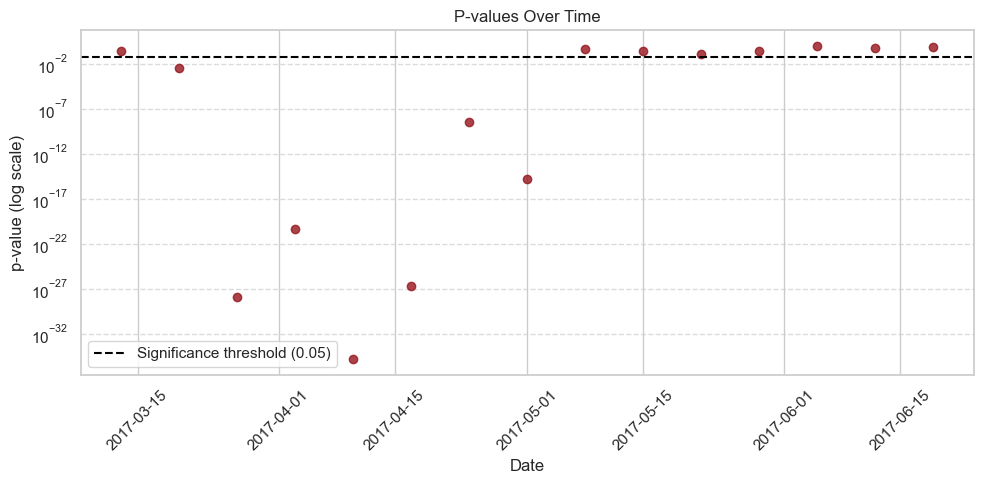

In [124]:
# ============================================================
# Plot: P-values over time (with save to Figures)
# ============================================================
import matplotlib.pyplot as plt
from pathlib import Path

plt.figure(figsize=(10, 5))

plt.scatter(
    df["date"],
    df["p_value"],
    color="#96151D",
    alpha=0.8
)

plt.axhline(
    y=0.05,
    linestyle='--',
    color="black",
    label="Significance threshold (0.05)"
)

plt.yscale("log")

plt.title("P-values Over Time")
plt.xlabel("Date")
plt.ylabel("p-value (log scale)")

plt.xticks(rotation=45)
plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

# ============================================================
# Save figure to ../Figures
# ============================================================
figures_dir = Path.cwd().parent / "Figures"
figures_dir.mkdir(exist_ok=True)

plt.savefig(
    figures_dir / "pvalues_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [116]:
import statsmodels.api as sm

X = sm.add_constant(weekly_effect["time_index"])
y = weekly_effect["effect"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 effect   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     8.077
Date:                Thu, 26 Mar 2026   Prob (F-statistic):             0.0139
Time:                        16:16:08   Log-Likelihood:                 26.041
No. Observations:                  15   AIC:                            -48.08
Df Residuals:                      13   BIC:                            -46.67
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1167      0.023      5.182      0.0

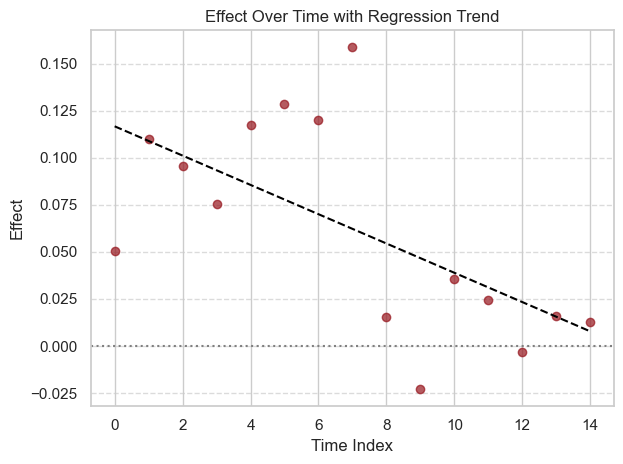

In [123]:
# ============================================================
# Plot: Effect over time (with save to Figures)
# ============================================================
import matplotlib.pyplot as plt
from pathlib import Path

plt.figure()

plt.scatter(
    weekly_effect["time_index"],
    weekly_effect["effect"],
    color="#96151D",
    alpha=0.7
)

plt.plot(
    weekly_effect["time_index"],
    model.predict(X),
    linestyle="--",
    color="black"
)

plt.axhline(0, linestyle=":", color="gray")

plt.title("Effect Over Time with Regression Trend")
plt.xlabel("Time Index")
plt.ylabel("Effect")

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

# ============================================================
# Save figure to ../Figures
# ============================================================
figures_dir = Path.cwd().parent / "Figures"
figures_dir.mkdir(exist_ok=True)

plt.savefig(
    figures_dir / "effect_over_time_decay.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Conclusions about duration assessment 


The weekly chi-square tests reveal that the experimental effect is not stable over time.

During the early weeks of the experiment (March to April), there are multiple statistically significant differences between the control and test groups, indicating a strong effect of the new design.

However, in later weeks (May to June), most p-values are not significant, suggesting that the effect diminishes or disappears over time.

This pattern indicates that the results are time-dependent and not consistent throughout the experiment period. Therefore, while the overall timeframe is sufficient in length, the instability of the effect suggests that conclusions based solely on aggregated results may be misleading.

The experiment captures short-term effects, but these are not sustained, highlighting the importance of analyzing temporal dynamics when evaluating experimental outcomes.


To assess whether the treatment effect changes over time, we regressed the weekly treatment effect (difference in completion rates between test and control) on a time index.

The results show a statistically significant negative coefficient for time (β = -0.0078, p = 0.014), indicating that the effect of the new design decreases over time.

This provides strong evidence of a decay effect, meaning that the initial impact of the new design is not sustained throughout the experiment period.

While the experiment timeframe is sufficient to capture short-term effects, the presence of a significant decay suggests that these effects are transient rather than persistent.

Therefore, conclusions based on aggregate results may overestimate the long-term impact of the new design.

### What other data could enhance the analysis? 

The analysis could be significantly improved with additional data, particularly:

* Historical behavior
Past usage of online channels
Previous interactions with similar processes

to help distinguishing baseline behavior vs experiment effect

* Temporal data
Time of day / day of week
Session timing patterns

for external behavioral patterns

* Geographic or segmentation data
Region or market segment
Customer segment (e.g., retail vs premium)

It identifies heterogeneous effects across segments


* Prior product usage / relationship depth
Product mix
Account types
Investment activity

It helps understanding client complexity and financial engagement
